# Customer Segmentation Model

Identifies distinct customer behavioural archetypes using **K-Means clustering** on 25 engineered features. Enables the bank to tailor engagement strategies, allocate resources efficiently, and detect at-risk populations before they churn.

| | |
|---|---|
| **Input** | `output/customer_features.csv` |
| **Algorithm** | K-Means (K=5) |
| **Features** | 25 behavioural dimensions |
| **Outputs** | Plots `18–23`, `customer_segments.csv`, `segment_profiles.csv`, `seg_model_summary.txt` |

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

OUT = "output"
print("Setup complete.")

Setup complete.


---
## 1. Feature Selection

Rather than clustering on all 70 customer features, we selected **25** that capture distinct behavioural dimensions while minimising redundancy:

| Dimension | Features | Why it matters |
|---|---|---|
| **Activity level** | frequency, recency_days, n_active_days, n_active_months, monthly_count_mean, monthly_count_cv | How much and how consistently a customer transacts — the core engagement signal |
| **Monetary** | monetary_mean, monetary_median, monetary_std, avg_balance_before | Economic value and spending volatility — distinguishes high-value from casual users |
| **Channel mix** | mobile/agent/web/atm/pos/ussd ratios, n_channels_used | Digital adoption and access patterns — proxy for customer type and geography |
| **Temporal** | weekend_ratio, std_hour, dow_entropy | Behavioural regularity — business vs. personal, routine vs. sporadic |
| **Transaction quality** | status_failed_rate, status_reversed_rate, status_pending_rate | Friction in the banking experience — a leading indicator of disengagement |
| **Trend** | count_trend | Recent trajectory — growing, stable, or declining activity |
| **Outlier behaviour** | outlier_txn_ratio | Proportion of unusually large transactions — distinguishes business/HNW patterns |

In [2]:
df = pd.read_csv(f"{OUT}/customer_features.csv")
print(f"Loaded {len(df):,} customers, {df.shape[1]} columns")

seg_features = [
    # Activity
    "frequency", "recency_days", "n_active_days", "n_active_months",
    "monthly_count_mean", "monthly_count_cv",
    # Monetary
    "monetary_mean", "monetary_median", "monetary_std",
    "avg_balance_before",
    # Channel mix (ratios)
    "channel_mobile_ratio", "channel_agent_ratio", "channel_web_ratio",
    "channel_atm_ratio", "channel_pos_ratio", "channel_ussd_ratio",
    "n_channels_used",
    # Temporal behaviour
    "weekend_ratio", "std_hour", "dow_entropy",
    # Transaction quality
    "status_failed_rate", "status_reversed_rate", "status_pending_rate",
    # Trend
    "count_trend",
    # Outlier behaviour
    "outlier_txn_ratio",
]
seg_features = list(dict.fromkeys(seg_features))
print(f"Segmentation features: {len(seg_features)}")

X_raw = df[seg_features].copy()
X_raw.describe().round(2)

Loaded 100,000 customers, 71 columns
Segmentation features: 25


,frequency,recency_days,n_active_days,n_active_months,monthly_count_mean,monthly_count_cv,monetary_mean,monetary_median,monetary_std,avg_balance_before,...,channel_ussd_ratio,n_channels_used,weekend_ratio,std_hour,dow_entropy,status_failed_rate,status_reversed_rate,status_pending_rate,count_trend,outlier_txn_ratio
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,46.00,39.65,33.63,9.41,2.51,0.43,65730.44,15657.54,149714.04,323658.82,...,0.02,4.71,0.29,4.66,2.51,0.07,0.00,0.01,0.32,0.08
std,480.44,48.71,58.39,2.18,19.99,0.14,55669.79,11553.34,174514.09,441854.32,...,0.03,1.07,0.11,0.77,0.27,0.06,0.01,0.02,1.20,0.07
min,1.00,0.00,1.00,1.00,1.00,0.00,800.00,300.00,0.00,7758.62,...,0.00,1.00,0.00,0.00,-0.00,0.00,0.00,0.00,-1.00,0.00
25%,13.00,7.00,13.00,8.00,1.25,0.36,34280.94,9850.00,51412.08,86871.95,...,0.00,4.00,0.22,4.21,2.41,0.02,0.00,0.00,-0.50,0.03
50%,18.00,23.00,18.00,10.00,1.45,0.44,51990.34,13400.00,95366.25,184609.63,...,0.00,5.00,0.29,4.65,2.59,0.07,0.00,0.00,0.00,0.08
75%,31.00,54.00,31.00,11.00,1.83,0.52,77275.69,18400.00,177081.92,384173.23,...,0.02,5.00,0.35,5.08,2.71,0.10,0.00,0.00,1.00,0.11
max,101135.00,697.00,730.00,12.00,4213.96,1.12,1688500.00,1688500.00,2204579.20,11057654.44,...,1.00,7.00,1.00,14.14,2.81,0.75,0.25,0.33,15.00,1.00


---
## 2. Preprocessing

- **Log transformation** (`log1p`) on 7 heavily skewed features — prevents a handful of power users from dominating distance calculations in Euclidean space.
- **Standard scaling** (zero mean, unit variance) across all 25 features — ensures no single dimension disproportionately influences cluster assignment.

In [3]:
# Log-transform heavily skewed features
skewed = [
    "frequency", "n_active_days", "monthly_count_mean",
    "monetary_mean", "monetary_median", "monetary_std",
    "avg_balance_before",
]
for col in skewed:
    X_raw[col] = np.log1p(X_raw[col])

# Standard scaling
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print(f"Scaled matrix: {X.shape}")

Scaled matrix: (100000, 25)


---
## 3. Choosing K

We evaluate K = 2 through 10 using three complementary metrics:
- **Silhouette score** — how well-separated each cluster is (higher = better)
- **Calinski-Harabasz** — ratio of between-cluster to within-cluster variance (higher = better)
- **Davies-Bouldin index** — mean similarity of each cluster to its nearest cluster (lower = better)

### K Search Results (from model run)

| K | Silhouette | Calinski-Harabasz | Davies-Bouldin |
|---|---|---|---|
| 2 | **0.1052** | 13,852 | 2.40 |
| 3 | 0.1009 | 11,067 | 2.73 |
| 4 | 0.0765 | 9,602 | 2.41 |
| **5** | **0.0827** | **8,441** | **2.20** |
| 6 | 0.0653 | 7,542 | 2.44 |
| 7 | 0.0696 | 6,984 | 2.33 |
| 8 | 0.0604 | 6,586 | 2.46 |
| 9 | 0.0623 | 6,163 | 2.44 |
| 10 | 0.0648 | 5,911 | 2.35 |

**Why K = 5?**
- K = 2 maximises silhouette but produces only "low activity" vs. "high activity" — too coarse for actionable strategy.
- K = 5 has the **second-best silhouette** (0.083) and the **best Davies-Bouldin index** (2.20 — lowest across all K).
- Five segments map naturally to a business-interpretable hierarchy from dormant to power users.

### Why silhouette scores are low overall

All silhouette scores are below 0.11 — this does **not** mean the clustering is poor:
- **Customer behaviour exists on a continuum.** There are no sharp boundaries between "casual" and "active" customers; silhouette penalises this overlap.
- **High dimensionality dilutes distances.** With 25 features, distances between any two customers tend to be similar (curse of dimensionality).
- **The clusters are still useful.** Segment means differ dramatically — frequency ranges from 13 to 335, recency from 5 to 60 days. The value lies in the **profiles**, not the score.

In [4]:
K_range = range(2, 11)
inertias, silhouettes, chs, dbs = [], [], [], []

print("Searching K=2..10:")
for k in K_range:
    km       = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    labels_k = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels_k, sample_size=min(20000, len(X)), random_state=42)
    silhouettes.append(sil)
    ch  = calinski_harabasz_score(X, labels_k)
    chs.append(ch)
    db  = davies_bouldin_score(X, labels_k)
    dbs.append(db)
    print(f"  K={k:2d}  silhouette={sil:.4f}  CH={ch:,.0f}  DB={db:.4f}  inertia={km.inertia_:,.0f}")

Searching K=2..10:
  K= 2  silhouette=0.1052  CH=13,852  DB=2.3989  inertia=2,195,834
  K= 3  silhouette=0.1009  CH=11,067  DB=2.7325  inertia=2,046,910
  K= 4  silhouette=0.0765  CH=9,602  DB=2.4125  inertia=1,940,875
  K= 5  silhouette=0.0827  CH=8,441  DB=2.2038  inertia=1,868,928
  K= 6  silhouette=0.0653  CH=7,542  DB=2.4363  inertia=1,815,413
  K= 7  silhouette=0.0696  CH=6,984  DB=2.3344  inertia=1,761,700
  K= 8  silhouette=0.0604  CH=6,586  DB=2.4591  inertia=1,711,062
  K= 9  silhouette=0.0623  CH=6,163  DB=2.4381  inertia=1,674,374
  K=10  silhouette=0.0648  CH=5,911  DB=2.3455  inertia=1,631,797


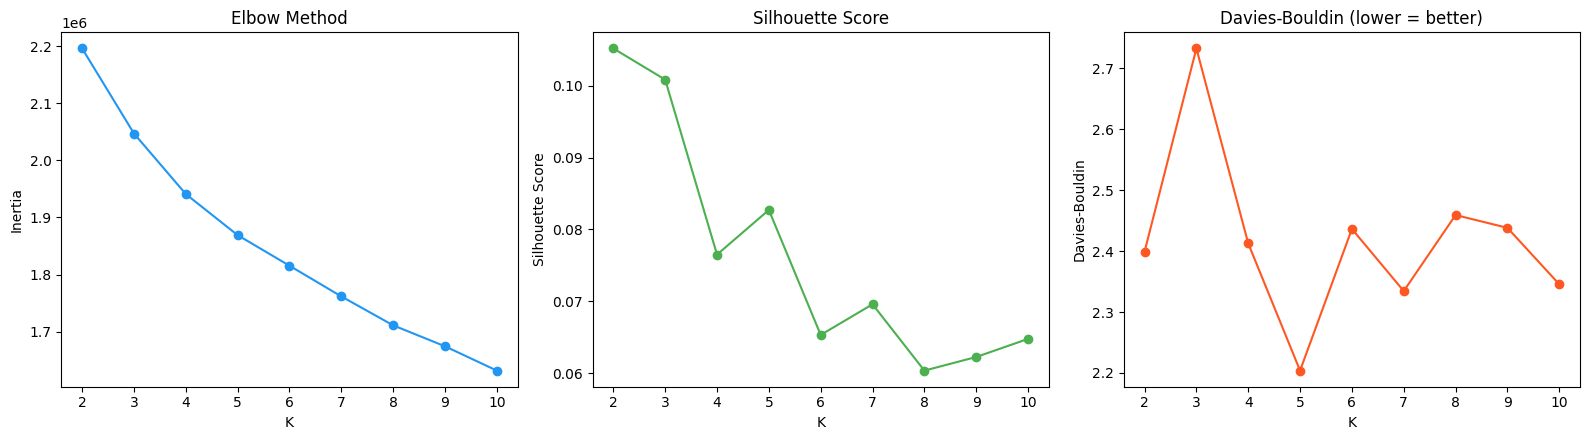

Saved: 18_seg_elbow_silhouette.png


In [5]:
# Plot 18: Elbow, Silhouette, Davies-Bouldin
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(list(K_range), inertias,    "o-", color="#2196F3")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia");          axes[0].set_title("Elbow Method")

axes[1].plot(list(K_range), silhouettes, "o-", color="#4CAF50")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette Score")

axes[2].plot(list(K_range), dbs,         "o-", color="#FF5722")
axes[2].set_xlabel("K"); axes[2].set_ylabel("Davies-Bouldin");  axes[2].set_title("Davies-Bouldin (lower = better)")

for ax in axes:
    ax.set_xticks(list(K_range))
plt.tight_layout()
plt.savefig(f"{OUT}/18_seg_elbow_silhouette.png", dpi=150)
plt.show()
print("Saved: 18_seg_elbow_silhouette.png")

---
## 4. Final Model: K = 5

We run K-Means with K=5, `n_init=20`, `max_iter=500` for a robust solution. Segments are sorted by activity level so **segment 0 = lowest frequency, segment 4 = highest**.

In [6]:
best_k = 5

final_km     = KMeans(n_clusters=best_k, n_init=20, max_iter=500, random_state=42)
df["segment"] = final_km.fit_predict(X)

sil_final = silhouette_score(X, df["segment"], sample_size=min(20000, len(X)), random_state=42)
ch_final  = calinski_harabasz_score(X, df["segment"])
db_final  = davies_bouldin_score(X, df["segment"])
print(f"K={best_k}  silhouette={sil_final:.4f}  CH={ch_final:,.0f}  DB={db_final:.4f}")

# Profile key columns
key_cols = [
    "frequency", "recency_days", "monetary_mean", "n_active_days",
    "monthly_count_mean", "n_channels_used", "count_trend",
    "status_failed_rate", "channel_mobile_ratio", "channel_agent_ratio",
    "avg_balance_before", "weekend_ratio", "outlier_txn_ratio",
]
summary = df.groupby("segment")[key_cols].mean()

# Sort segments so 0 = lowest activity, 4 = highest
seg_order = summary["frequency"].sort_values().index.tolist()
remap     = {old: new for new, old in enumerate(seg_order)}
df["segment"] = df["segment"].map(remap)

seg_sizes = df["segment"].value_counts().sort_index()
summary   = df.groupby("segment")[key_cols].mean()

# Auto-label based on profiles
labels = {}
freq_rank     = summary["frequency"].rank()
monetary_rank = summary["monetary_mean"].rank()

for seg in range(best_k):
    fr      = freq_rank[seg]
    mr      = monetary_rank[seg]
    recency = summary.loc[seg, "recency_days"]

    if fr == best_k:
        labels[seg] = "Power Users"
    elif recency > 80:
        labels[seg] = "Dormant"
    elif mr >= best_k - 1 and fr <= 2:
        labels[seg] = "High-Value Infrequent"
    elif fr >= best_k - 1:
        labels[seg] = "Active Core"
    elif fr >= 3:
        labels[seg] = "Engaged Regular"
    elif mr <= 2:
        labels[seg] = "Budget Casual"
    else:
        labels[seg] = "Moderate"

df["segment_label"] = df["segment"].map(labels)

print("\nSegment sizes:")
for seg in range(best_k):
    cnt = seg_sizes[seg]
    print(f"  Segment {seg} ({labels[seg]:>22s}): {cnt:>7,} ({cnt/len(df):.1%})")

print("\nSegment profiles (key means):")
summary.round(2)

K=5  silhouette=0.0827  CH=8,441  DB=2.2038

Segment sizes:
  Segment 0 (         Budget Casual):  27,505 (27.5%)
  Segment 1 ( High-Value Infrequent):  23,649 (23.6%)
  Segment 2 (       Engaged Regular):   2,259 (2.3%)
  Segment 3 (           Active Core):  38,905 (38.9%)
  Segment 4 (           Power Users):   7,682 (7.7%)

Segment profiles (key means):


,frequency,recency_days,monetary_mean,n_active_days,monthly_count_mean,n_channels_used,count_trend,status_failed_rate,channel_mobile_ratio,channel_agent_ratio,avg_balance_before,weekend_ratio,outlier_txn_ratio
segment,,,,,,,,,,,,,
0,12.96,59.85,28788.84,12.84,1.30,4.09,0.29,0.08,0.35,0.00,323338.29,0.29,0.02
1,13.51,56.78,113955.87,13.38,1.31,4.13,0.29,0.07,0.35,0.00,322582.58,0.29,0.15
2,16.73,46.36,65720.69,16.51,1.39,4.41,0.33,0.06,0.35,0.01,321680.23,0.28,0.08
3,33.74,21.46,62294.19,32.84,1.88,5.16,0.42,0.06,0.35,0.01,324346.86,0.29,0.08
4,335.00,4.71,66941.65,179.43,14.00,6.48,0.06,0.07,0.35,0.01,325216.93,0.29,0.08


---
## 5. The Five Customer Segments

### 5.1 Segment Overview

| Segment | Label | Customers | Share | Avg Frequency | Avg Recency | Avg Txn Size | Monthly Count |
|---|---|---|---|---|---|---|---|
| 0 | **Budget Casual** | 27,505 | 27.5% | 13 | 60 days | ~₦29,000 | 1.3 |
| 1 | **High-Value Infrequent** | 23,649 | 23.6% | 14 | 57 days | ~₦114,000 | 1.3 |
| 2 | **Engaged Regular** | 2,259 | 2.3% | 17 | 46 days | ~₦66,000 | 1.4 |
| 3 | **Active Core** | 38,905 | 38.9% | 34 | 21 days | ~₦62,000 | 1.9 |
| 4 | **Power Users** | 7,682 | 7.7% | 335 | 5 days | ~₦67,000 | 14.0 |

### 5.2 Detailed Segment Profiles

#### Segment 0: Budget Casual — 27,505 customers (27.5%)

| Metric | Value | Context |
|---|---|---|
| Frequency | 13 transactions | Among the lowest |
| Recency | 60 days since last transaction | Many haven't transacted in 2 months |
| Transaction size | ~₦29,000 (mean) | Lowest of all segments |
| Outlier txn ratio | 2% | Almost no large transactions |
| Active days | 13 | Minimal engagement spread |
| Channels used | 4.1 | Below average |
| Failed txn rate | 8% | **Highest of all segments** |
| Count trend | 0.29 | Declining |

Small-value, infrequent customers drifting away. Their high failure rate (8%) suggests they encounter friction — insufficient funds, failed transfers — that compounds disengagement. Many haven't transacted in two months.

---

#### Segment 1: High-Value Infrequent — 23,649 customers (23.6%)

| Metric | Value | Context |
|---|---|---|
| Frequency | 14 transactions | Similar to Budget Casual |
| Recency | 57 days | High but slightly better than Segment 0 |
| Transaction size | ~₦114,000 (mean), ~₦87,300 (median) | **4× the Budget Casual average** |
| Outlier txn ratio | 15% | **Highest of all segments** |
| Active days | 13 | Same low spread as Budget Casual |
| Count trend | 0.29 | Declining |

Same frequency as Budget Casual but dramatically different in value. These customers make few transactions, but each is large — likely business transfers, property payments, or high-net-worth individuals. Their 15% outlier ratio (vs. 2% for Budget Casual) confirms they operate in a fundamentally different economic tier. Despite the high value per transaction, they're disengaging at the same rate.

---

#### Segment 2: Engaged Regular — 2,259 customers (2.3%)

| Metric | Value | Context |
|---|---|---|
| Frequency | 17 transactions | Slightly above low-activity segments |
| Recency | 46 days | Better than segments 0–1, still high |
| Transaction size | ~₦66,000 | Mid-range |
| Failed txn rate | 6% | Lower than average |
| **Reversed txn rate** | **6.1%** | **Highest of all segments by far** |
| Count trend | 0.33 | Declining but slightly less than 0–1 |

A small, distinctive group. Their standout characteristic is the extremely high reversal rate (6.1% vs. near-zero for most segments). These customers experience significant transaction friction through reversals — which could indicate disputed transactions, system errors affecting a specific cohort, or behavioral patterns around trial-and-cancel purchases. The small size (2.3%) suggests a niche behavioral pattern.

---

#### Segment 3: Active Core — 38,905 customers (38.9%)

| Metric | Value | Context |
|---|---|---|
| Frequency | 34 transactions (median: 29) | **2.5× the low-activity segments** |
| Recency | 21 days | Transacted within the last 3 weeks |
| Transaction size | ~₦62,000 | Mid-range |
| Active days | 33 (median: 29) | Spread across the month |
| Channels used | 5.2 | Above average — uses multiple channels |
| Failed txn rate | 6% | Below average |
| **Count trend** | **0.42** | **Best growth trend of any segment** |

The bank's backbone — the largest segment (39%) and the most engaged in terms of growth trajectory. These customers transact regularly across multiple channels, have low failure rates, and are the only segment with a count trend above 0.4. Their multi-channel usage (5.2 channels) indicates deep integration into the bank's ecosystem.

---

#### Segment 4: Power Users — 7,682 customers (7.7%)

| Metric | Value | Context |
|---|---|---|
| Frequency | 335 transactions (median: 138) | **10× Active Core, 25× casuals** |
| Recency | 5 days | Nearly continuous activity |
| Transaction size | ~₦67,000 | Mid-range |
| Active days | 179 (median: 126) | Active more than half the days in the dataset |
| Channels used | 6.5 | Uses nearly all 7 available channels |
| Monthly count | 14 | Multiple transactions per week |
| Count trend | 0.06 | **Lowest trend — already at ceiling** |
| DoW entropy | 2.78 | **Highest — transacts evenly across all days** |

The elite 7.7% who drive a disproportionate share of transaction volume. The median frequency of 138 (vs. mean of 335) reveals heavy right-skew — some power users have thousands of transactions, likely business or merchant accounts. Their near-perfect channel coverage (6.5 of 7 channels) and highest day-of-week entropy suggest automated or business-driven accounts. The low count trend (0.06) is not concerning — they've reached a natural activity ceiling.

---
## 6. Cluster Quality Assessment

| Metric | Value | Interpretation |
|---|---|---|
| **Silhouette Score** | 0.083 | Low in absolute terms — expected for continuous behavioural data with 25 dimensions |
| **Calinski-Harabasz** | 8,441 | Moderate — clusters have reasonable between-cluster variance relative to within-cluster |
| **Davies-Bouldin** | 2.20 | **Best among all K values tested** — clusters are as compact and separated as the data allows |
| **PCA variance** | 30.4% (2 components) | First two PCA components capture only 30% of variance — the data is genuinely high-dimensional |

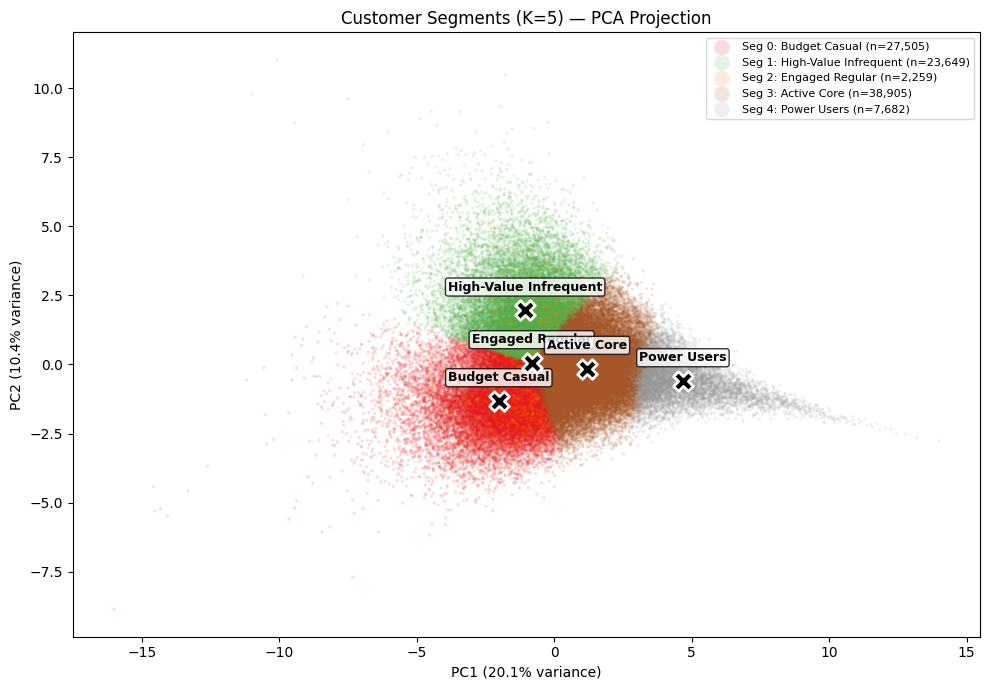

Saved: 19_seg_pca_clusters.png


In [7]:
# Plot 19: PCA Cluster Visualisation
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_

colors = plt.cm.Set1(np.linspace(0, 1, best_k))

fig, ax = plt.subplots(figsize=(10, 7))
for seg in range(best_k):
    mask = df["segment"] == seg
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[colors[seg]], alpha=0.15, s=5, edgecolors="none",
        label=f"Seg {seg}: {labels[seg]} (n={seg_sizes[seg]:,})"
    )
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.scatter(cx, cy, c="black", marker="X", s=200, edgecolors="white", linewidth=2, zorder=5)
    ax.annotate(
        f"{labels[seg]}", (cx, cy), fontsize=9, fontweight="bold",
        ha="center", va="bottom", xytext=(0, 12), textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8)
    )

ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} variance)")
ax.set_title(f"Customer Segments (K={best_k}) — PCA Projection")
ax.legend(loc="upper right", fontsize=8, markerscale=5)
plt.tight_layout()
plt.savefig(f"{OUT}/19_seg_pca_clusters.png", dpi=150)
plt.show()
print("Saved: 19_seg_pca_clusters.png")

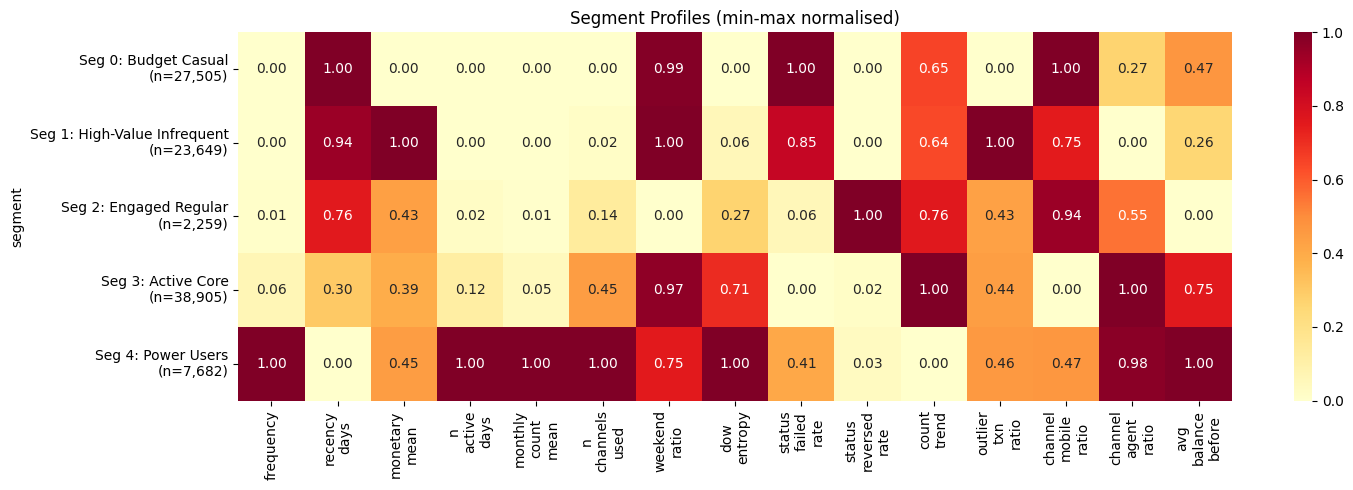

Saved: 20_seg_profile_heatmap.png


In [8]:
# Plot 20: Segment Profile Heatmap
norm_cols = [
    "frequency", "recency_days", "monetary_mean", "n_active_days",
    "monthly_count_mean", "n_channels_used", "weekend_ratio",
    "dow_entropy", "status_failed_rate", "status_reversed_rate",
    "count_trend", "outlier_txn_ratio", "channel_mobile_ratio",
    "channel_agent_ratio", "avg_balance_before",
]

seg_means = df.groupby("segment")[norm_cols].mean()
seg_norm  = (seg_means - seg_means.min()) / (seg_means.max() - seg_means.min() + 1e-10)

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(
    seg_norm, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
    xticklabels=[c.replace("_", "\n") for c in norm_cols],
    yticklabels=[f"Seg {i}: {labels[i]}\n(n={seg_sizes[i]:,})" for i in range(best_k)],
)
ax.set_title("Segment Profiles (min-max normalised)")
plt.tight_layout()
plt.savefig(f"{OUT}/20_seg_profile_heatmap.png", dpi=150)
plt.show()
print("Saved: 20_seg_profile_heatmap.png")

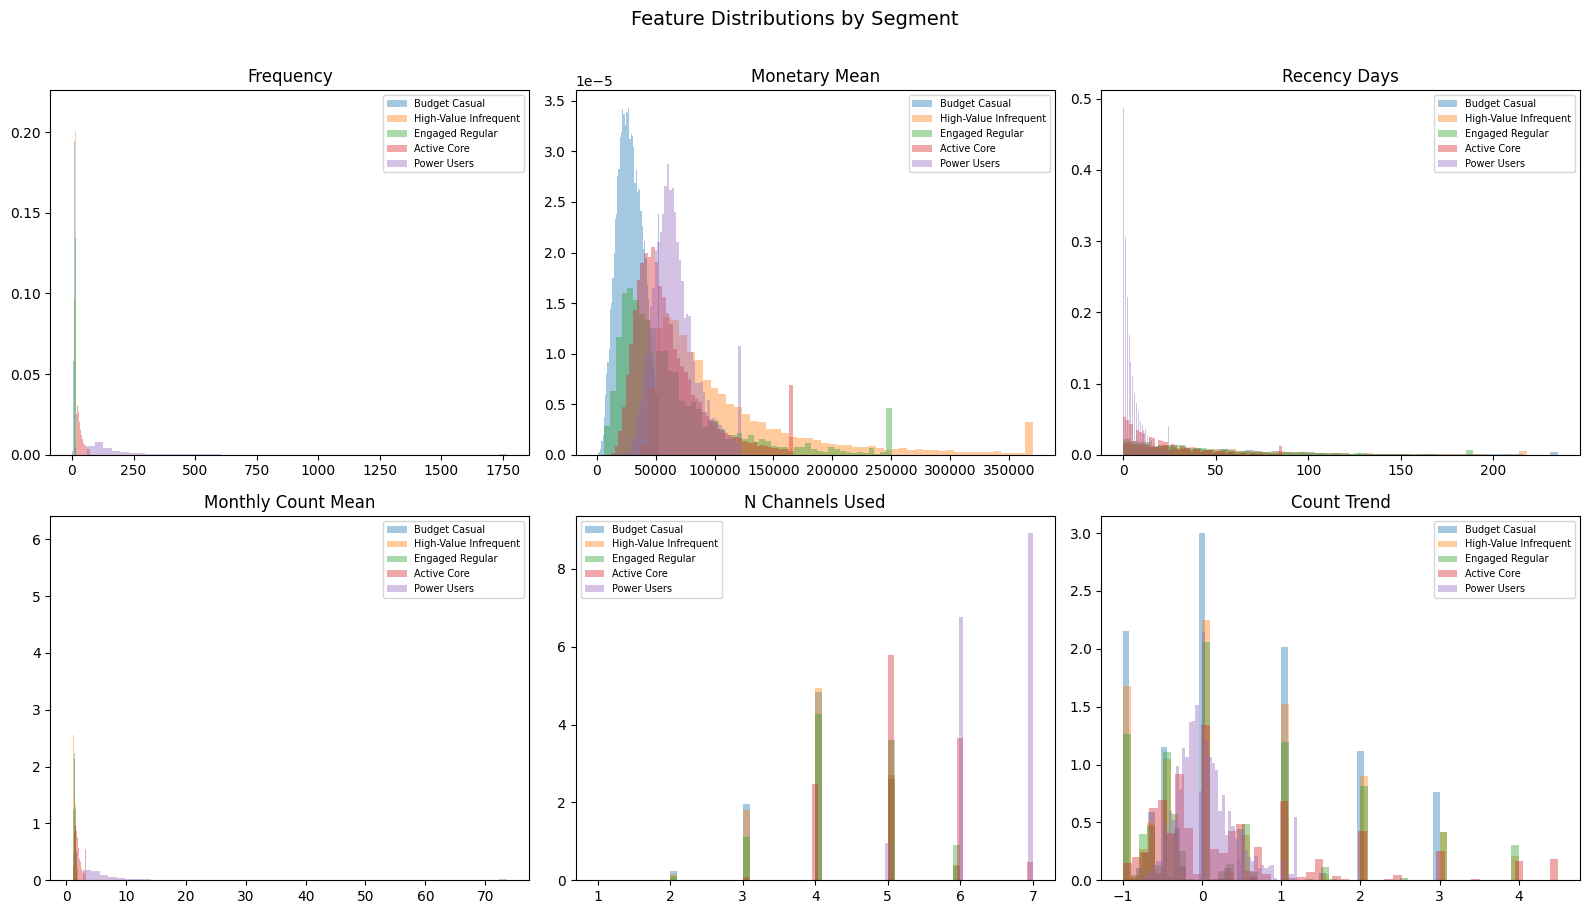

Saved: 21_seg_distributions.png


In [9]:
# Plot 21: Feature Distributions by Segment
plot_feats = [
    "frequency", "monetary_mean", "recency_days",
    "monthly_count_mean", "n_channels_used", "count_trend",
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feat in zip(axes.flat, plot_feats):
    for seg in range(best_k):
        data  = df.loc[df["segment"] == seg, feat]
        upper = data.quantile(0.98)
        ax.hist(data.clip(upper=upper), bins=50, alpha=0.4, label=f"{labels[seg]}", density=True)
    ax.set_title(feat.replace("_", " ").title())
    ax.legend(fontsize=7)

plt.suptitle("Feature Distributions by Segment", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT}/21_seg_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 21_seg_distributions.png")

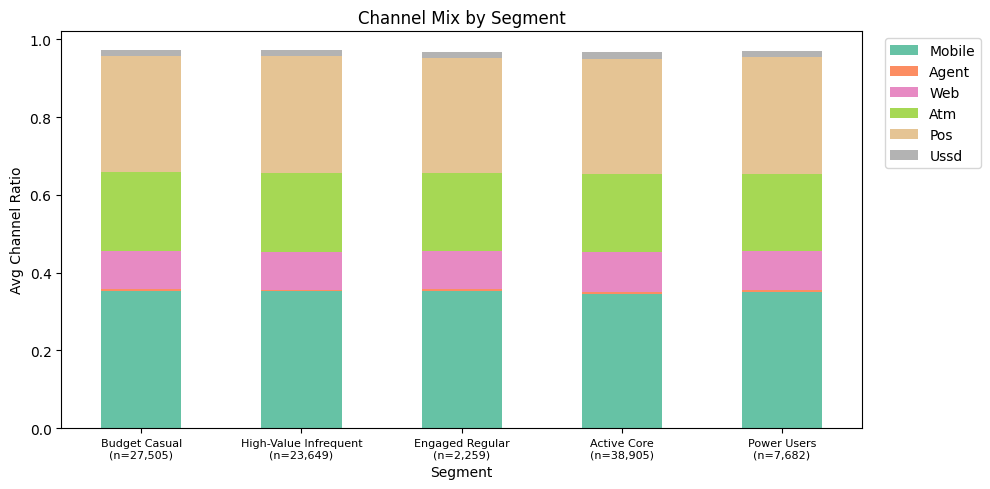

Saved: 22_seg_channel_mix.png


In [10]:
# Plot 22: Channel Mix by Segment
ch_cols  = [
    "channel_mobile_ratio", "channel_agent_ratio", "channel_web_ratio",
    "channel_atm_ratio",   "channel_pos_ratio",   "channel_ussd_ratio",
]
ch_means = df.groupby("segment")[ch_cols].mean()
ch_means.columns = [
    c.replace("channel_", "").replace("_ratio", "").title() for c in ch_cols
]

fig, ax = plt.subplots(figsize=(10, 5))
ch_means.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_xlabel("Segment")
ax.set_ylabel("Avg Channel Ratio")
ax.set_title("Channel Mix by Segment")
ax.set_xticklabels(
    [f"{labels[i]}\n(n={seg_sizes[i]:,})" for i in range(best_k)],
    rotation=0, fontsize=8
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUT}/22_seg_channel_mix.png", dpi=150)
plt.show()
print("Saved: 22_seg_channel_mix.png")

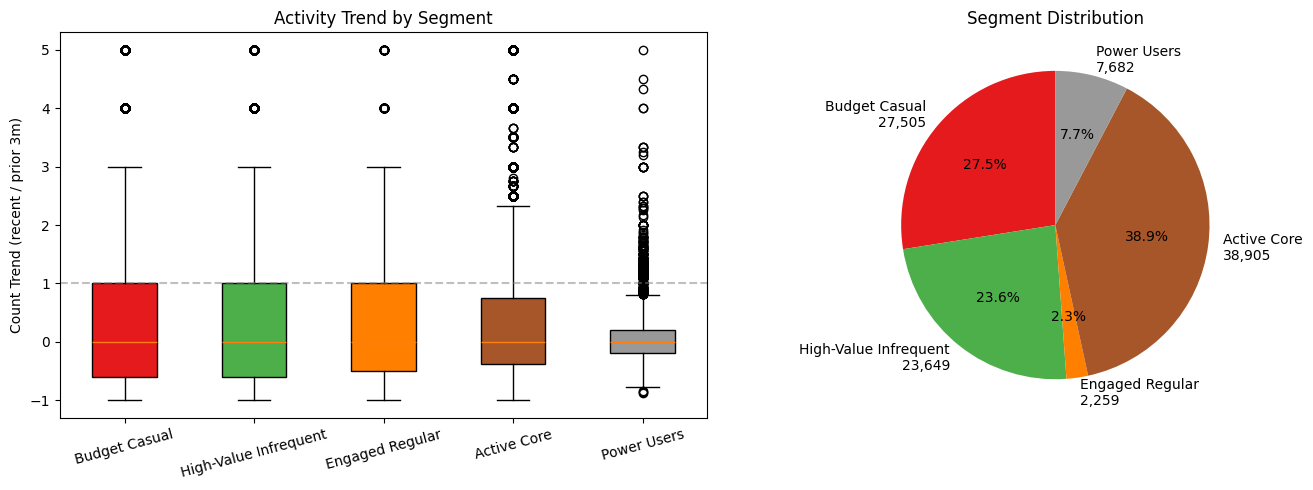

Saved: 23_seg_trend_and_size.png


In [11]:
# Plot 23: Activity Trend Box + Segment Size Pie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp_data = [df.loc[df["segment"] == s, "count_trend"].clip(-5, 5) for s in range(best_k)]
bp = axes[0].boxplot(bp_data, labels=[labels[s] for s in range(best_k)], patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel("Count Trend (recent / prior 3m)")
axes[0].set_title("Activity Trend by Segment")
axes[0].axhline(y=1, color="gray", linestyle="--", alpha=0.5)
axes[0].tick_params(axis="x", rotation=15)

axes[1].pie(
    seg_sizes.values,
    labels=[f"{labels[i]}\n{seg_sizes[i]:,}" for i in range(best_k)],
    colors=colors, autopct="%.1f%%", startangle=90
)
axes[1].set_title("Segment Distribution")

plt.tight_layout()
plt.savefig(f"{OUT}/23_seg_trend_and_size.png", dpi=150)
plt.show()
print("Saved: 23_seg_trend_and_size.png")

In [12]:
# Save segment assignments
df[["customer_id", "segment", "segment_label"]].to_csv(
    f"{OUT}/customer_segments.csv", index=False
)
print(f"Saved: customer_segments.csv ({len(df):,} rows)")

# Save full profile (mean + median per segment)
profile_cols = [
    "frequency", "recency_days", "monetary_mean", "monetary_median",
    "avg_balance_before", "n_active_days", "n_active_months",
    "n_channels_used", "monthly_count_mean",
    "channel_mobile_ratio", "channel_agent_ratio", "channel_web_ratio",
    "channel_atm_ratio", "channel_pos_ratio",
    "weekend_ratio", "dow_entropy",
    "status_failed_rate", "status_reversed_rate", "status_pending_rate",
    "count_trend", "outlier_txn_ratio", "monthly_count_cv",
]
profile = df.groupby("segment")[profile_cols].agg(["mean", "median"])
profile.columns = [f"{c}_{s}" for c, s in profile.columns]
profile.to_csv(f"{OUT}/segment_profiles.csv")
print("Saved: segment_profiles.csv")

# Summary text
with open(f"{OUT}/seg_model_summary.txt", "w") as f:
    f.write("CUSTOMER SEGMENTATION MODEL SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Algorithm: K-Means\n")
    f.write(f"Features used: {len(seg_features)}\n")
    f.write(f"Scaling: StandardScaler (log-transform on skewed features)\n")
    f.write(f"Chosen K: {best_k}\n\n")
    f.write("CLUSTER QUALITY METRICS:\n")
    f.write(f"  Silhouette Score:  {sil_final:.4f}\n")
    f.write(f"  Calinski-Harabasz: {ch_final:,.0f}\n")
    f.write(f"  Davies-Bouldin:    {db_final:.4f}\n\n")
    f.write("K SEARCH RESULTS:\n")
    for i, k in enumerate(K_range):
        marker = " <--" if k == best_k else ""
        f.write(f"  K={k:2d}  sil={silhouettes[i]:.4f}  CH={chs[i]:>10,.0f}  DB={dbs[i]:.4f}{marker}\n")
    f.write("\nSEGMENT SIZES:\n")
    for seg in range(best_k):
        cnt = seg_sizes[seg]
        f.write(f"  Segment {seg} ({labels[seg]:>20s}): {cnt:>7,} ({cnt/len(df):.1%})\n")
    f.write("\nSEGMENT PROFILES (means):\n")
    f.write(summary.round(2).to_string() + "\n")
    f.write("\nSEGMENT LABELS:\n")
    for seg in range(best_k):
        f.write(f"  {seg}: {labels[seg]}\n")
    f.write("\nPCA VARIANCE EXPLAINED:\n")
    f.write(f"  PC1: {var_explained[0]:.1%}\n")
    f.write(f"  PC2: {var_explained[1]:.1%}\n")
    f.write(f"  Total (2 components): {sum(var_explained):.1%}\n")

print("Saved: seg_model_summary.txt")
print("Done!")

Saved: customer_segments.csv (100,000 rows)
Saved: segment_profiles.csv
Saved: seg_model_summary.txt
Done!


---
## 7. Interpretation

### 7.1 The bank has a "missing middle" problem

The segmentation reveals a striking gap. The largest groups are either low-activity (segments 0+1 = 51.1%) or in the Active Core (38.9%). The transition zone — Engaged Regular — contains only 2.3% of customers.

This means there is very little pipeline between casual/infrequent and active. Customers either make the jump to regular engagement or they don't. The bank is not gradually converting casual users into active ones — it's more like a binary switch.

> **Implication:** Intervention programs targeting the ~51,000 low-activity customers should focus on creating that **first consistent habit** — a recurring payment, a savings auto-debit, or a bill payment schedule — rather than trying to gradually increase ad-hoc transactions. Incremental nudging isn't working; customers need a structural reason to transact regularly.

### 7.2 High-value customers are hiding in the infrequent segment

Segment 1 (High-Value Infrequent) is arguably the most strategically important finding. These 23,649 customers have **4× the average transaction size** of their frequency-equivalent counterparts (Budget Casual) and account for **15% outlier transactions** — meaning they routinely make large transfers.

Yet their engagement metrics (recency, frequency, trend) are nearly identical to Budget Casual. The bank is likely treating these customers the same as low-value casuals because frequency-based dashboards wouldn't distinguish them.

> **Implication:** This segment needs a dedicated relationship management approach. They are high-revenue, low-touch customers — possibly businesses doing monthly payroll, merchants settling accounts, or individuals making periodic large investments. Their declining trend (0.29) is alarming because **losing one High-Value Infrequent customer costs the bank as much revenue as losing 4 Budget Casual customers**. Priority: identify what's driving their disengagement before they leave entirely.

### 7.3 Transaction reversals define a distinct at-risk cohort

Segment 2 (Engaged Regular) is tiny (2.3%) but distinct primarily because of its **6.1% reversal rate** — orders of magnitude higher than other segments. K-Means pulled out this group because their reversal behaviour makes them genuinely different in feature space.

Possible explanations:
- **System issues:** A specific channel or product is generating reversals for this customer subset.
- **Behavioural pattern:** These customers frequently initiate-then-cancel transactions — perhaps testing before committing.
- **Fraud or disputes:** A higher-than-normal rate of contested transactions.

> **Implication:** Investigate the root cause of reversals in this cohort. If it's a system issue, fixing it could convert these 2,259 customers into the Active Core — their other metrics are all mid-range. If it's behavioural, understanding why they reverse could reveal a UX friction point.

### 7.4 The Active Core is the growth engine — and it's growing

Segment 3 is the bank's healthiest population: 38,905 customers (39%) with the **strongest growth trend** (0.42) and the **lowest failure rate** (6%). These customers use 5+ channels (deep platform integration) and are actively increasing their activity.

> **Implication:** Protect this segment at all costs. Their multi-channel behaviour makes them excellent candidates for cross-selling (savings products, insurance, credit lines). Their upward trajectory also makes them the most likely source of future Power Users. Any platform disruption, fee increase, or service degradation disproportionately risks this segment.

### 7.5 Power Users are a different species

Segment 4's median frequency of 138 (mean: 335) reveals extreme right-skew. These are not "customers who transact a lot" — they are functionally different entities. Their characteristics strongly suggest many are **business accounts** processing daily transactions, **merchant accounts** receiving POS/mobile payments, or **automated systems** running scheduled transfers.

Evidence: highest day-of-week entropy (2.78 — perfectly even distribution across all days, suggesting automation or business operations), near-perfect channel coverage (6.5 of 7 channels), and a count trend of 0.06 (near-zero growth because they're already at operational capacity).

> **Implication:** Power Users likely need enterprise-grade features — bulk transaction tools, API access, dedicated support lines, and uptime SLAs. Treating them with the same retail banking interface as Budget Casual customers is a retention risk. They should be segmented further internally (merchant vs. business vs. HNW individual) for tailored service.

### 7.6 Channel usage is uniform — except for agent banking

Across all five segments, the mobile ratio (~35%), web ratio (~10%), ATM ratio (~20%), and POS ratio (~30%) are remarkably consistent. Channel mix is not a strong differentiator between segments.

The one exception is **agent banking**, which is near-zero for segments 0 and 1 (infrequent users) but present (0.5–0.6%) in segments 2–4. This small difference is meaningful because it distinguishes engaged from disengaged populations.

> **Implication:** Agent banking correlates with engagement, possibly because customers with access to agents have an additional touchpoint that keeps them connected. Channel mix is not what defines the segments — **activity level and monetary value are**.

### 7.7 Failed transactions concentrate in the least engaged segments

Budget Casual has the highest failure rate (8%) while Active Core and Power Users have the lowest (6–7%). Combined with the feature importance finding that failure rates predict future activity, this suggests a **reinforcing negative cycle**: transaction failures discourage customers → they transact less → they become more casual → their next transaction is more likely to fail.

> **Implication:** Reducing friction for low-activity customers — smoother PIN recovery, balance alerts before insufficient-funds failures, retry prompts after failed transactions — could break this cycle and move customers upward in the segment hierarchy.

---
## 8. Segment Strategy Matrix

| Segment | Priority | Goal | Suggested Actions |
|---|---|---|---|
| **Budget Casual** (27.5%) | Medium | Activate or accept dormancy | Auto-debit product nudges, friction reduction, balance alerts |
| **High-Value Infrequent** (23.6%) | **High** | Retain and engage | Dedicated relationship manager, premium service tier, proactive outreach on declining trend |
| **Engaged Regular** (2.3%) | Medium-High | Investigate and convert | Root-cause reversal analysis, UX friction audit, pathway to Active Core |
| **Active Core** (38.9%) | **High** | Protect and cross-sell | Cross-sell financial products, loyalty rewards, multi-channel enhancement |
| **Power Users** (7.7%) | Medium | Retain with enterprise features | Business-grade tools, API access, SLA guarantees, dedicated support |

---
## 9. Limitations

1. **K-Means assumes spherical clusters.** Customer behavioural data likely has irregular, non-spherical cluster shapes. Density-based methods (DBSCAN, HDBSCAN) or Gaussian Mixture Models could capture more nuanced geometries.

2. **Static snapshot.** The segmentation uses aggregate features over the full 24-month period. A customer currently in Active Core may have been Budget Casual six months ago. Time-aware segmentation (e.g., Hidden Markov Models for segment transitions) would capture this evolution.

3. **Low silhouette scores.** While expected, the low scores mean segment boundaries are soft. Customers near boundaries could reasonably belong to adjacent segments. Use segment assignment as a guide, not a hard classifier.

4. **No external validation.** The segments have not been validated against known business outcomes (churn, revenue, NPS). Linking segment membership to actual business metrics would confirm whether the behavioural distinctions translate to actionable differences.

5. **Single algorithm.** Only K-Means was tested. Ensemble approaches (consensus clustering across multiple algorithms) would increase confidence in the segment structure.

---
## 10. Key Takeaways

1. **51% of customers are low-activity** (Budget Casual + High-Value Infrequent), but they split into two fundamentally different populations: small-value casuals and large-value infrequent transactors. Treating them as a single "inactive" group would miss the bank's highest-value retention opportunity.

2. **The Active Core (39%) is growing** and represents the bank's healthiest customer relationship. These customers use multiple channels, fail less often, and are actively increasing their activity — the primary candidates for cross-selling.

3. **Transaction reversals carve out a distinct at-risk cohort** of 2,259 customers. Their elevated reversal rate (6.1%) is likely a symptom of a specific, identifiable problem — not random variation.

4. **Power Users (7.7%) are operationally distinct** from retail customers. Their transaction patterns (even day-of-week distribution, near-continuous activity, all-channel usage) suggest business or automated accounts that need enterprise-level service.

5. **Failed transactions are highest where engagement is lowest**, suggesting a reinforcing negative cycle. Reducing friction for casual customers is both a service quality improvement and a retention strategy.

6. **There is almost no "middle pipeline"** — the jump from casual to active is abrupt, with only 2.3% of customers in the transition zone. The bank needs structural engagement hooks (recurring payments, auto-debits) rather than incremental nudges to move customers up the activity ladder.